## 3.10 Inception networks

* __If residual networks was all about going deeper, the Inception networks is all about going wider__, as a way to increase the final network depth. 
* The Inception network came to the world in 2014 when a group of researchers at Google published their paper "_Going Deeper with Convolutions_" (https://arxiv.org/abs/1409.4842).
* The main hallmark of this architecture is __building a deeper neural network while improving the utilization of the computing resources inside the network__. 
* One particular incarnation of the Inception network is called _GoogLeNet_. 

### 3.10.1. Inception modules

* There are some architectural decisions that you need to make for each layer when you are designing a CNN:

    - __The kernel size of the convolutional layer__: 
        - When designing the convolutional layer, we find ourselves trying to pick and tune the kernel size of each layer that fits our dataset. 
        - Smaller kernels capture finer details of the image, whereas bigger filters will leave out minute details.
    - __When to use the pooling layer__: 
        - AlexNet uses pooling layers every one or two convolutional layers to downsize spatial features. 
        - VGGNet applies pooling after every two, three, or four convolutional layers as the network gets deeper.

* Configuring the kernel size and positioning the pool layers are decisions we make mostly by trial and error and experiment with to get the optimal results. 

__why not let the model choose?__

* __Instead of choosing a desired filter size in a convolutional layer and deciding where to place the pooling layers, let’s apply all of them all together in one block and call it the inception module.__
* Let the next layer of the model gets to decide if (and how) to use each piece of information.
* The architecture is then developed by stacking the inception modules on top of each other. 

#### Naïve inception module

* The inception module is a combination of four layers:
    - __1×1 convolutional layer__, looking for cross-channel correlations
    - __3×3 convolutional layer__, looking for finner spatial correlations
    - __5×5 convolutional layer__, looking for more-abstract spatial correlations
    - __3×3 max-pooling layer__, trying to downsize spatial features.
* The outputs of these layers are concatenated into a single output volume forming the input of the next stage.
* We use the `same` padding so the output has the same length as the original input. We do that because we want the output to have width and height dimensions similar to the input to simplify the depth concatenation process.

<img src="images/CNNs/inception_module_naive.png" width=723 height=318/>

#### Problem with the naïve inception module

* We’ve drastically increased computational costs. 
    - Large (e.g. 5×5) convolutional filters are inherently expensive to compute
    - Stacking multiple different filters side by side greatly increases the number of feature maps per layer. 

### 3.10.2. Dimensionality reduction layer

#### 1×1 Convolutions: Sharing and reshaping information in channels

* Convolutions with a kernel size greater than one are used to capture _spatial_ information.
* But a convolution with __a kernel size of 1 captures _no spatial information___.
* At first glance, this seems to make a convolution a useless operation.
* However, there can be valuable reasons to use a convolution with this kind of neighbor blindness:
    - One particular application is as a computationally __cheap operation to change the number of channels at a given layer__.
    - Another is that 1x1 convolutions __share information across channels__, rather than looking at neighboring locations.
* In summary, with a 1x1 convolution we are telling the network to focus on the patterns found at this location instead of having it try to build new spatial patterns.
* __Example__:
    - If we are processing an image, and one channel has learned to identify horizontal edges, another vertical edges, another edges at a 45-degree angle, and so on.
    - If we want a channel to learn to identify any edge, we can accomplish that by looking just at the channel values (i.e., have any of these angle-dependent edge-detecting filters fired?) without considering the neighboring pixels.
    - If such identifications are useful, 1x1 convolutions can help improve learning and reduce computational cost.

<img src="images/CNNs/convolutions_1x1.png" width=700 />

####  Use a 1×1 convolutional layer as a dimensionality reduction layer.

* As previously said, a 1×1 convolutional layer preserves the spatial dimensions (height and width) of the input volume but changes the number of channels of the volume (depth).

* We have already use them in the residual networks to adjust the depth of the residual connection.

<img src="images/CNNs/bottleneck_layer_1x1_conv.png" width=698 height=260/>

#### Example of dimensionality reduction

* __Original__
    - Input volume with dimensions of 32 × 32 × 200.
    - if we apply 32 filters with kernel size of 5×5. 
    - Total number of multiplications: 32 × 32 × 200 multiplied by 5 × 5 × 32 = more than 163 million operations. 

* __With dimensionality reduction__
    * We add a 1×1 convolutional layer with a depth of 16 to reduce the dimension volume from 200 to 16 channels. 
    * We can then apply the 5×5 convolutional layer on the output, which has much less depth.
    * The total number of multiplications in this operation is 16.3 million, which is a tenth of the 163 million multiplications that we calculated without the reduce layers.

* __Conclusion__
    * By dividing the convolution in two separate parts we obtain the same size at the output with much less operations.


<img src="images/CNNs/bottleneck_layer_1.png" width=564 height=353/>

#### Bottleneck layers

* The 1×1 convolutional layers are also known as bottleneck layers because by reducing the dimensionality of the network makes it look like a bottleneck:

<img src="images/CNNs/bottleneck_layer_2.png" width=560 height=207/>

### 3.10.3. Inception module with dimensionality reduction

* We mantain the 1x1 convolution to look for cross-channel correlations.
* We add a 1×1 convolutional layer before the bigger kernels (3×3 and 5×5), to reduce their depth, which in turn will reduce the number of operations.
* We will also add a 1×1 convolutional layer after the 3×3 max-pooling layer because pooling layers don’t reduce the depth for their inputs. So, we will need to apply the reduce layer to their output before we do the concatenation.
* The design follows the practical intuition that visual information should be processed at various scales and then aggregated so that the next stage can abstract features from the different scales simultaneously.

<img src="images/CNNS/inception_module_dimensionality_reduction.png" width=687 height=377/>

### 3.10.4. Inception module in Keras

* Keras do not have pre-build inception modules but they are easy to create with the `Conv2D` and `MaxPool2D` layers.

In [1]:
# Keras code for the inception_module

def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce,
                     filters_5x5, filters_pool_proj, name=None):
    
    # 1×1 route
    conv_1x1 = Conv2D(filters_1x1, kernel_size=(1, 1), padding='same', activation='relu',
               kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
 
    # 3×3 route = 1×1 CONV + 3×3 CONV 
    pre_conv_3x3 = Conv2D(filters_3x3_reduce, kernel_size=(1, 1), padding='same',
                   activation='relu', kernel_initializer=kernel_init, 
                   bias_initializer=bias_init)(x)
    
    conv_3x3 = Conv2D(filters_3x3, kernel_size=(3, 3), padding='same', activation='relu', 
               kernel_initializer=kernel_init, 
               bias_initializer=bias_init)(pre_conv_3x3)
      
    # 5×5 route = 1×1 CONV + 5×5 CONV 
    pre_conv_5x5 = Conv2D(filters_5x5_reduce, kernel_size=(1, 1), padding='same',
                   activation='relu', kernel_initializer=kernel_init, 
                   bias_initializer=bias_init)(x)
    
    conv_5x5 = Conv2D(filters_5x5, kernel_size=(5, 5), padding='same', activation='relu', 
                  kernel_initializer=kernel_init, 
                  bias_initializer=bias_init)(pre_conv_5x5)
    
    # pool route = POOL + 1×1 CONV 
    pool_proj = MaxPool2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu',
                  kernel_initializer=kernel_init, bias_initializer=bias_init)(pool_proj)
 
    # final concatenation
    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=3,  name=name)
 
    return output

### 3.10.5. Inception architecture

* The Inception network architecture consists of stacking inception modules on top of each other, and add a 3×3 pooling layer in between for downsampling.


<img src="images/CNNs/inception_architecture.png" width=621 height=544/>


#### Inception V1 network (GoogLeNet)

* The full GoogLeNet model consists of three parts: the first part has the classical CNN architecture like AlexNet an LeNet, the second part is a stack of inception modules and pooling layers, and the third part is the traditional fully connected classifiers.

<img src="images/CNNs/googlenet_architecture.png" width=500 />

* Full image of Inception V1 network (GoogLeNet)

![inception_v1.png](images/CNNs/inception_v1.png)

#### Inception V3 network

* The inception architecture received several updates.
* Version 3 is described here: https://arxiv.org/abs/1512.00567 
* We can create pre-trained inception V3 models with the `inceptionv3` function. See: https://keras.io/api/applications/inceptionv3/

![inception_v3.png](images/CNNs/inception_v3.png)

#### InceptionResNetV2

* Later versions included residual connections to the Inception architecture, such as the InceptionResNetV2 available in Keras: https://keras.io/api/applications/inceptionresnetv2/
* See: https://arxiv.org/abs/1602.07261

<img src="images/CNNs/InceptionResNetV2.png" width=900 />

#### Cats and dogs example with a InceptionResNetV2 network with random initial weights

* Let's load the small cats-vs-dogs dataset again

In [2]:
import keras
from keras import layers
from keras.layers import Input, Conv2D, MaxPool2D, BatchNormalization, concatenate, AveragePooling2D, Dense, Dropout

In [3]:
import os, shutil, pathlib
#base_dir = pathlib.Path("/mnt/c/datasets/cats_vs_dogs_small")
base_dir = pathlib.Path("c:/datasets/dogs-vs-cats_small")

from keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
    base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [4]:
from keras.applications import InceptionResNetV2

In [5]:
conv_base = InceptionResNetV2(
    weights=None,
    include_top=False)

In [6]:
conv_base.summary()

Model: "inception_resnet_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,216 │ activation[0][0]  │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,432 │ activation_1[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      5,120 │ max_pooling2d[0]… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │    138,240 │ activation_3[0][… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, None,      │          0 │ batch_normalizat

 Total params: 54,336,736 (207.28 MB)

 Trainable params: 54,276,192 (207.05 MB)

 Non-trainable params: 60,544 (236.50 KB)

In [7]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)
  
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.inception_resnet_v2.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [8]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="inception.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=100, 
    validation_data=validation_dataset, 
    callbacks=callbacks) 

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5315 - loss: 18.2568 - val_accuracy: 0.5360 - val_loss: 0.7795
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4818 - loss: 10.1322 - val_accuracy: 0.5160 - val_loss: 0.7143
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5012 - loss: 3.2025 - val_accuracy: 0.5010 - val_loss: 61.9263
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.4923 - loss: 3.3084 - val_accuracy: 0.5020 - val_loss: 0.6982
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5311 - loss: 1.0101 - val_accuracy: 0.5220 - val_loss: 0.7050
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.5607 - loss: 0.7491 - val_accuracy: 0.5000 - val_loss: 0.7084
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.6020 - loss: 0.6889 - val_accuracy: 0.6120 - val_loss: 0.6633
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6641 - loss: 0.6349 - val_accuracy: 0

In [9]:
import matplotlib.pyplot as plt

def plot(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "b-o", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "r-o", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "b-o", label="Training loss")
    plt.plot(epochs, val_loss, "r-o", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

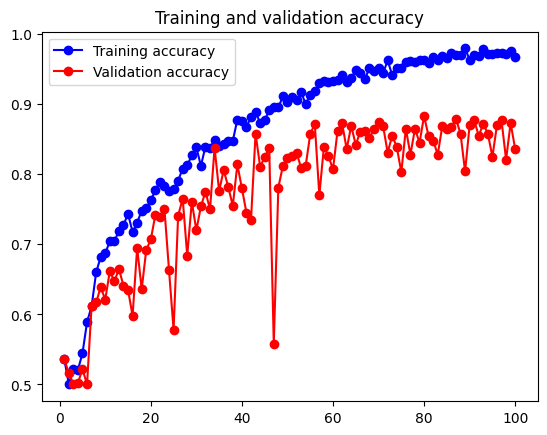

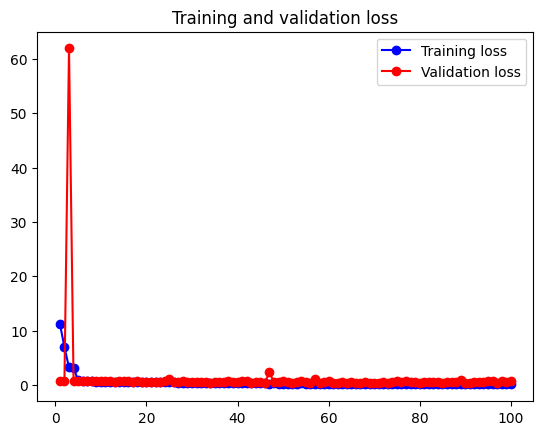

In [10]:
plot(history)

In [11]:
model.load_weights("inception.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 341ms/step - accuracy: 0.8667 - loss: 0.4041
Test accuracy: 0.850


## 3.11. Depthwise separable convolutions (Xception networks)

* Source of images: 
    * https://eli.thegreenplace.net/2018/depthwise-separable-convolutions-for-machine-learning/
    * https://towardsdatascience.com/a-basic-introduction-to-separable-convolutions-b99ec3102728
    * https://towardsdatascience.com/a-comprehensive-introduction-to-different-types-of-convolutions-in-deep-learning-669281e58215

### 3.11.1. Normal convolutions

* A convolution layer attempts to learn filters in a 3D space, with 2 spatial dimensions (width and height) and a channel dimension.
* Thus a single convolution kernel is tasked with simultaneously mapping cross-channel correlations and spatial correlations.
* The number of trainable parameters and the number of operations to perform the convolution are considerable (notabily if the kernel dimension is high).
* Let's define the following __variables__:
    * `S`: spatial dimension - width and height, assuming square inputs.
    * `F`: filter width and height, assuming square filter.
    * `inC`: number of input channels.
    * `outC`: number of output channels.
* Padding
    - We also assume `same` padding, so that the spatial size of the output matches the input.
    - If we were not using padding then spatial size would shrink by two tiles alongside each dimension. So we would need to considerate as spatial dimensions (`S`-2)x(`S`-2).

<img src="images/CNNs/conv2d-3d-annotated.png" width=500 />

* __Parameters = `F` x `F` x `inC` x `outC`__
    * (`F` x `F` x `inC`) is the dimension of a 3D filter
    * `outC` is the number of filters
    
    
* __Operations = `F` x `F` x `inC` x `S` x `S` x `outC`__
    * (`F` x `F` x `inC`) at each position of the spatial dimension
    * (`S` x `S`) multiplied by the size of the spatial dimension (input size)
    * `outC` multiplied by the number of filters (output channels)
    
    
* __Example: `S`=128, `F`=3, `inC`=3, `outC`=16__
    * __Parameters__: 3 x 3 x 3 x 16 = __432__
    * __Operations__: 3 x 3 x 3 x 128 x 128 x 16 = __7.077.888__

### 3.11.2. Spatial separable convolutions

* A spatial separable convolution simply divides a kernel into two, smaller kernels. The most common case would be to divide a 3x3 kernel into a 3x1 and 1x3 kernel, like so:

<img src="images/CNNs/spatial_separable_convolutions_1.webp" width=400/>

* Now, instead of doing one convolution with 9 multiplications, we do two convolutions with 3 multiplications each (6 in total) to achieve the same effect. 
* With less multiplications, computational complexity goes down, and the network is able to run faster.

<img src="images/CNNs/spatial_separable_convolutions_2.webp" width=619 height=318/>

* The main issue with the spatial separable convolution is that not all kernels can be “separated” into two, smaller kernels. 
* This becomes particularly bothersome during training, if we replace all traditional convolutions by the spatially separable convolution, we limit ourselves for searching all possible kernels and the training results may be sub-optimal.


### 3.11.3. Depthwise separable convolutions

#### Inception architectures

* A normal convolutional kernel is tasked with simultaneously mapping cross-channel correlations and spatial correlations
* This idea behind the Inception module is to make this process easier and more efficient by explicitly factoring it into a series of operations that would independently look at cross-channel correlations (the 1x1 convolution step) and at spatial correlations (the normal convolution step).
* The fundamental hypothesis behind Inception is that __cross-channel correlations and spatial correlations are sufficiently decoupled that it is preferable not to map them jointly__.

#### Xception architectures

* The Xception architecture make the following hypothesis: that __the mapping of cross-channels correlations and spatial correlations in the feature maps of convolutional neural networks can be entirely decoupled__.
* Because this assumption is generally true for the image representations learned by deep neural networks, it serves as a useful prior that helps the model make more efficient use of its training data. 
* Since this hypothesis is a stronger version of the hypothesis underlying the Inception architecture, the authors named their proposed architecture __Xception__, which stands for "_Extreme Inception_" (see the original paper at https://arxiv.org/abs/1610.02357).

#### Depthwise separable convolutions

* A depthwise separable convolution __splits a kernel into 2 separate kernels that do two convolutions: the depthwise convolution and the pointwise convolution__.
* Unlike spatial separable convolutions, depthwise separable convolutions work with kernels that cannot be “factored” into two smaller kernels. Hence, it is more commonly used.

#### Depthwise convolution

* In the depthwise convolution, we give the input image a convolution without changing the depth.
* __It is a spatial convolution performed independently over each channel of an input__.
* __Parameters = `F` x `F` x `inC`__
    * (`F` x `F`) is the dimension of the filters used.
    * `inC` is the number of input channels.
* __Operations = `F` x `F` x `inC` x `S` x `S`__
    * (`F` x `F` x `inC`) at each position of the spatial dimension
    * (`S` x `S`) multiplied by the size of the spatial dimension (input size)
    

<img src="images/CNNs/conv2d-depthwise-annotated-up.png" width=800 />

#### Pointwise convolution

* __It is a 1x1 convolution, projecting the channels output by the depthwise convolution onto a new channel space__. 
* __Depthwise convolution calculation__
    * In the depthwise convolution, asuming a `same` padding, we have the same dimensions in the image (`S` x `S`) and the same depth `inC`
    * Now, we need to increase the number of channels of the image with the pointwise convolution.
    * The pointwise convolution is so named because it uses a 1x1 kernel
    * This kernel has a depth of `inC`, the number of channels of the input image.
    * We apply `outC` kernels to obtain `outC` channels in the output image.
* __Parameters = `inC` x `outC`__
    * `inC` is the number of input channels.
    * `outC` is the number of output channels.    
* __Operations = `inC` x `S` x `S` x `outC`__
    * `inC` times at each position of the spatial dimension
    * (`S` x `S`) multiplied by the size of the spatial dimension (input size)
    * multiplied by the number of output channels `outC`.


<img src="images/CNNs/conv2d-depthwise-annotated-down.png" width=800 />

__Total numbers of the depthwise separable convolution__
* __Parameters = (`F` x `F` x `inC`) + (`inC` x `outC`)__    
* __Operations = (`F` x `F` x `inC` x `S` x `S`) + (`inC` x `S` x `S` x `outC`)__  
* __Example: `S`=128, `F`=3, `inC`=3, `outC`=16__
    * __Parameters__: (3 x 3 x 3) + (3 x 16) = __75__
    * __Operations__: (3 x 3 x 3 x 128 x 128) + (3 x 128 x 128 x 16) = __1.228.800__

__In brief__:
    
* In the normal convolution, we are transforming the image `outC` (128) times.
* Operations = `F` x `F` x `inC` x [`S`-2] x [`S`-2] x `outC`
    - For the given example: 3 x 3 x 3 x 5 x 5 x 128 = 86.400

<img src="images/CNNs/standard_2d_convolution_128.webp" width=779 height=293/>


* In the separable convolution, we only really transform the image once — in the depthwise convolution. 
* Then, we take the transformed image and simply elongate it to `outC` (128) channels. Without having to transform the image over and over again, we can save up on computational power.

<img src="images/CNNs/depthwise_separable_convolution.webp" width=779 />

* Operations = (`F` x `F` x `inC` x [`S`-2] x [`S`-2]) + (`inC` x [`S`-2] x [`S`-2] x `outC`)
    - Example: (3 x 3 x 3 x 5 x 5) + (3 x 5 x 5 x 128) = 675 + 9.600 = 10.275

* __Advantages__: 
    * Depthwise separable convolution requires significantly fewer parameters and involves fewer computations compared to regular convolution, while having comparable representational power.
    * It results in smaller models that converge faster and are less prone to overfitting.
    * These advantages become especially important when you’re training small models from scratch on limited data.
    * This efficiency make depthwise separable convolution ideal for mobile computer vision models such as Google's MobileNet.
    
* __Disadvantages__: 
    * Because it reduces the number of parameters in a convolution, if your network is already small, you might end up with too few parameters and your network might fail to properly learn during training. 

### 3.11.4. Depthwise separable convolutions in Keras

* In Keras we can apply depthwise separable convolutions using the layer:  `keras.layers.SeparableConv2D`
* Let's create __a model with data augmentation, residual connections and depthwise separable convolutions__ and apply it to the __cats and dogs example__.

In [12]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

* After the data augmentation and rescaling layer we put a normal Convolutional 2D with 32 filters.
* Since separable convolutional layers only have one spatial filter per input channel, we should avoid using them after layers that have too few channels, such as the input layer.

In [13]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
 
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(x)
 
for size in [32, 64, 128, 256, 512]:
    residual = x
 
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)
  
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)
  
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
  
    residual = layers.Conv2D(size, 1, strides=2, padding="same", use_bias=False)(residual)
    x = layers.add([x, residual])

    
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

* We have created a deep CNN.

![cnn_augmentation_residual_depthwise-square.png](images/CNNs/cnn_augmentation_residual_depthwise-square.png)

In [14]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 180, 180,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 180, 180,  │          0 │ sequential_1[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_203 (Conv2D) │ (None, 176, 176,  │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 176, 176,  │        128 │ conv2d_203[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_203      │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 176, 176,  │      1,312 │ activation_203[0… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 176, 176,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_204      │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 176, 176,  │      1,312 │ activation_204[0… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 88, 88,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_204 (Conv2D) │ (None, 88, 88,    │      1,024 │ conv2d_203[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 88, 88,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │ conv2d_204[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        128 │ add[0][0]         │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_205      │ (None, 88, 88,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 88, 88,    │      2,336 │ activation_205[0… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        256 │ separable_conv2d

 Total params: 721,857 (2.75 MB)

 Trainable params: 718,849 (2.74 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [15]:
# All together
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])
  
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="all_together.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 708ms/step - accuracy: 0.5587 - loss: 0.7857 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 710ms/step - accuracy: 0.5885 - loss: 0.6586 - val_accuracy: 0.4990 - val_loss: 0.7118
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 711ms/step - accuracy: 0.6081 - loss: 0.6632 - val_accuracy: 0.5000 - val_loss: 0.7128
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 706ms/step - accuracy: 0.6295 - loss: 0.6430 - val_accuracy: 0.5000 - val_loss: 0.7096
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 708ms/step - accuracy: 0.6872 - loss: 0.6244 - val_accuracy: 0.5000 - val_loss: 0.7151
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 707ms/step - accuracy: 0.6786 - loss: 0.6046 - val_accuracy: 0.5020 - val_loss: 0.7951
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 709ms/step - accuracy: 0.6959 - loss: 0.5911 - val_accuracy: 0.5230 - val_loss: 0.7979
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 708ms/step - accuracy: 0.7059 - loss: 0.5525 - 

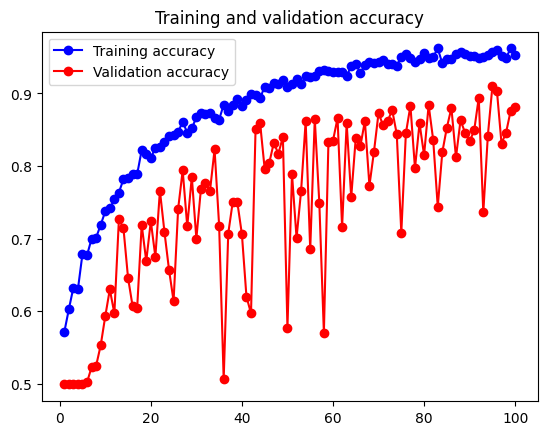

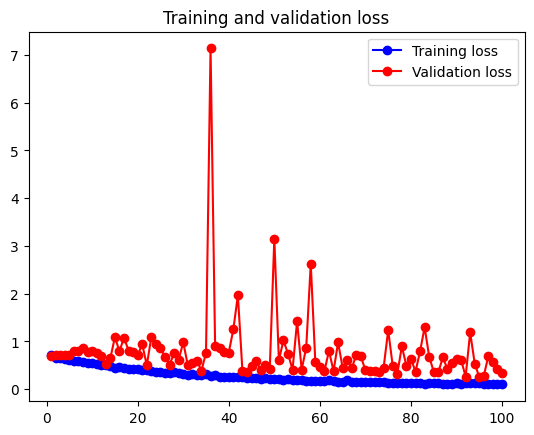

In [16]:
plot(history)

In [17]:
test_model = keras.models.load_model(
    "all_together.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.8982 - loss: 0.2672
Test accuracy: 0.896


<img src="images/CNNs/cats_dogs_results.png" width=1000 />